# Audio & Speech EDA
Debate dataset — 28 videos, 2656 segments across 8 candidates.

Goal: understand the distributions of speech features and whether candidates are distinguishable by how they speak.

In [21]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## Loading the data

In [22]:
audio_files = sorted([
    f for f in os.listdir('Project_Features')
    if f.endswith('_audio.pkl')
])

dfs = []
for f in audio_files:
    df = pd.read_pickle(os.path.join('Project_Features', f))
    df['video'] = f.replace('_audio.pkl', '')
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
print(f'{len(data)} segments, {data["video"].nunique()} debates')
print(f'Columns: {list(data.columns)}')

2656 segments, 28 debates
Columns: ['time stamp', 'duration', 'meanF0Hz', 'stdevF0Hz', 'HNR', 'localJitter', 'localabsoluteJitter', 'rapJitter', 'ppq5Jitter', 'ddpJitter', 'localShimmer', 'localdbShimmer', 'apq3Shimmer', 'apq5Shimmer', 'apq11Shimmer', 'ddaShimmer', 'f1_mean', 'f2_mean', 'f3_mean', 'f4_mean', 'f1_median', 'f2_median', 'f3_median', 'f4_median', 'npause', 'speechrate', 'articulationrate', 'asd', 'speak_embeddings', 'pF', 'fdisp', 'avgFormant', 'mff', 'video']


## Getting candidate labels from filenames

There's no speaker column — the audio pickle only stores segments with timestamps and features.
But each debate file is named `CandidateA_vs_CandidateB_Month_Day`, so we know exactly
which two people appear in each file. We can extract both names and use the speaker embeddings
to cluster each debate's segments into two groups, then assign names.

For now, a simpler first step: we can at least say which candidates *appear* in a given video,
and later use embedding clustering (k-means with k=2) to split them.

In [23]:
# All known candidates (from candidate_party.pkl)
CANDIDATES = [
    'Cotrim_Figueiredo', 'Filipe', 'Gouveia_Melo',
    'Marques_Mendes', 'Martins', 'Pinto', 'Seguro', 'Ventura'
]

# Party mapping
data_parties = pd.read_pickle(os.path.join('Project_Features', 'candidate_party.pkl'))
candidate_to_party = dict(zip(data_parties['Candidate'], data_parties['Party']))
print(candidate_to_party)

{'Gouveia_Melo': 'Independent', 'Marques_Mendes': 'PSD+CDS', 'Seguro': 'PS', 'Ventura': 'CH', 'Cotrim_Figueiredo': 'IL', 'Filipe': 'CDU', 'Martins': 'BE', 'Pinto': 'L'}


In [26]:
# Extract the two candidates from the video filename
def extract_candidates(video_name):
    """Returns (candidateA, candidateB) from video filename."""
    for c in CANDIDATES:
        if video_name.startswith(c):
            rest = video_name[len(c) + len('_vs_'):]
            for c2 in CANDIDATES:
                if rest.startswith(c2):
                    return c, c2
    return None, None

# Verify it works
print(extract_candidates('Ventura_vs_Filipe_December_13'))
print(extract_candidates('Cotrim_Figueiredo_vs_Gouveia_Melo_November_20'))

('Ventura', 'Filipe')
('Cotrim_Figueiredo', 'Gouveia_Melo')


In [27]:
from sklearn.cluster import KMeans

# For each debate, cluster segments into 2 speakers using speak_embeddings
# then assign candidate names based on cluster (cluster 0 = candidateA, 1 = candidateB)
# Note: cluster assignment is arbitrary — we just get two groups

labeled_dfs = []

for video_name, group in data.groupby('video'):
    cA, cB = extract_candidates(video_name)
    if cA is None:
        group = group.copy()
        group['candidate'] = 'unknown'
        labeled_dfs.append(group)
        continue

    embeddings = np.stack(group['speak_embeddings'].values)
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embeddings)

    group = group.copy()
    group['candidate'] = [cA if l == 0 else cB for l in labels]
    labeled_dfs.append(group)

data = pd.concat(labeled_dfs, ignore_index=True)
data['party'] = data['candidate'].map(candidate_to_party)

print('Segments per candidate:')
print(data['candidate'].value_counts())

Segments per candidate:
candidate
Martins              372
Pinto                334
Ventura              333
Cotrim_Figueiredo    332
Gouveia_Melo         330
Filipe               322
Marques_Mendes       320
Seguro               313
Name: count, dtype: int64


## Feature groups

We have 30 scalar features. They fall into 4 groups:

- **Pitch**: `meanF0Hz`, `stdevF0Hz`
- **Voice quality**: `HNR`, `localJitter`, `localShimmer` (one representative from each jitter/shimmer family)
- **Formants**: `f1_mean`, `f2_mean`, `f3_mean`, `f4_mean`, `fdisp`, `avgFormant`, `pF`, `mff`
- **Speech rate**: `speechrate`, `articulationrate`, `npause`, `asd`

For the correlation analysis we'll use the full set; for grouped plots we use one representative per group.

In [30]:
META = ['video', 'time stamp', 'duration', 'speak_embeddings', 'candidate', 'party']
scalar_cols = [c for c in data.columns if c not in META]

# Representative subset for grouped plots
KEY_FEATURES = [
    'meanF0Hz',       # pitch
    'stdevF0Hz',      # pitch variability
    'HNR',            # voice clarity
    'localJitter',    # pitch irregularity
    'localShimmer',   # amplitude irregularity
    'speechrate',     # words/sec
    'articulationrate', # syllables/sec
    'npause',         # number of pauses
    'asd',            # average syllable duration
    'f1_mean',        # first formant
    'f2_mean',        # second formant
    'fdisp',          # formant dispersion
]

print('Key features:', KEY_FEATURES)

Key features: ['meanF0Hz', 'stdevF0Hz', 'HNR', 'localJitter', 'localShimmer', 'speechrate', 'articulationrate', 'npause', 'asd', 'f1_mean', 'f2_mean', 'fdisp']


## Quick univariate overview

Just to check distribution shapes before going into group comparisons.

In [31]:
data[KEY_FEATURES].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
meanF0Hz,2656.0,153.812,31.455,84.690,129.671,149.873,177.109,235.532
stdevF0Hz,2656.0,33.276,9.977,9.947,26.100,32.623,39.792,72.745
HNR,2656.0,10.508,1.855,2.452,9.353,10.529,11.745,16.450
localJitter,2656.0,0.028,0.005,0.014,0.026,0.029,0.032,0.045
localShimmer,2656.0,0.111,0.017,0.067,0.099,0.110,0.122,0.169
speechrate,2656.0,4.740,0.601,2.126,4.359,4.755,5.127,6.914
articulationrate,2656.0,5.014,0.501,3.025,4.697,5.027,5.349,6.914
npause,2656.0,2.595,3.488,0.000,0.000,1.000,3.000,44.000
asd,2656.0,0.202,0.021,0.145,0.187,0.199,0.213,0.331
f1_mean,2656.0,459.627,44.087,346.147,427.024,455.753,487.726,650.846


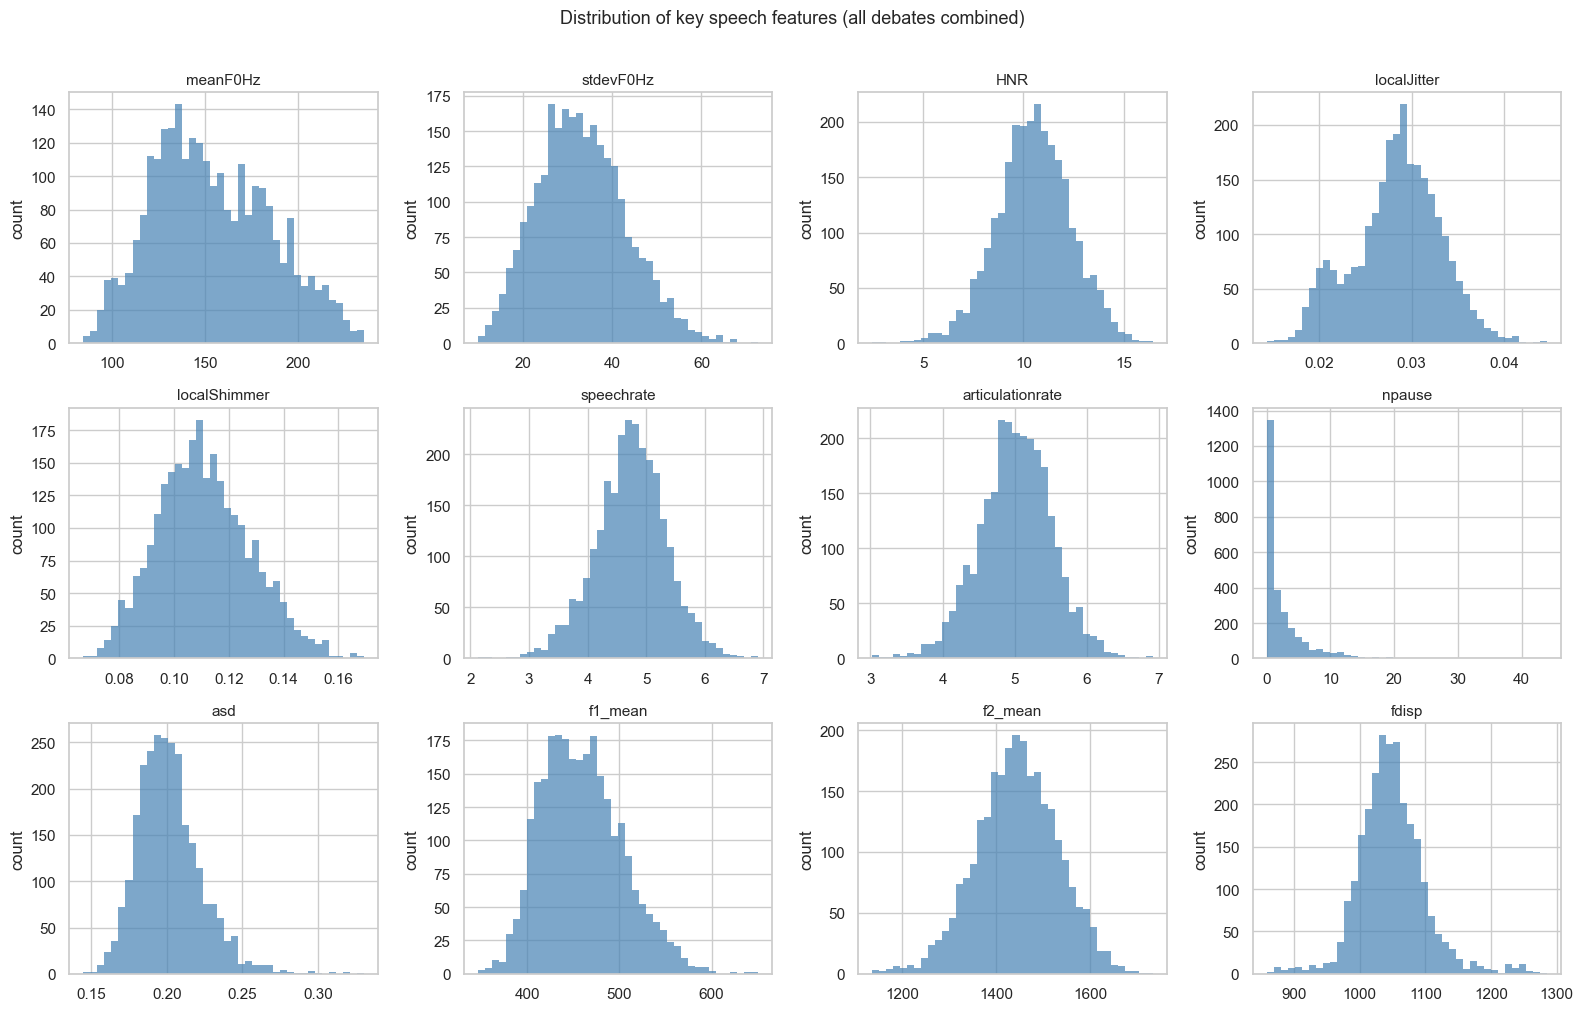

In [32]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(KEY_FEATURES):
    axes[i].hist(data[col].dropna(), bins=40, color='steelblue', alpha=0.7, edgecolor='none')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('count')

plt.suptitle('Distribution of key speech features (all debates combined)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Correlation heatmap

Which features move together? This guides what's worth plotting in bivariate analysis.
Strong correlations within the same group (jitter variants, formant variants) are expected —
more interesting are cross-group correlations like pitch vs. speech rate.

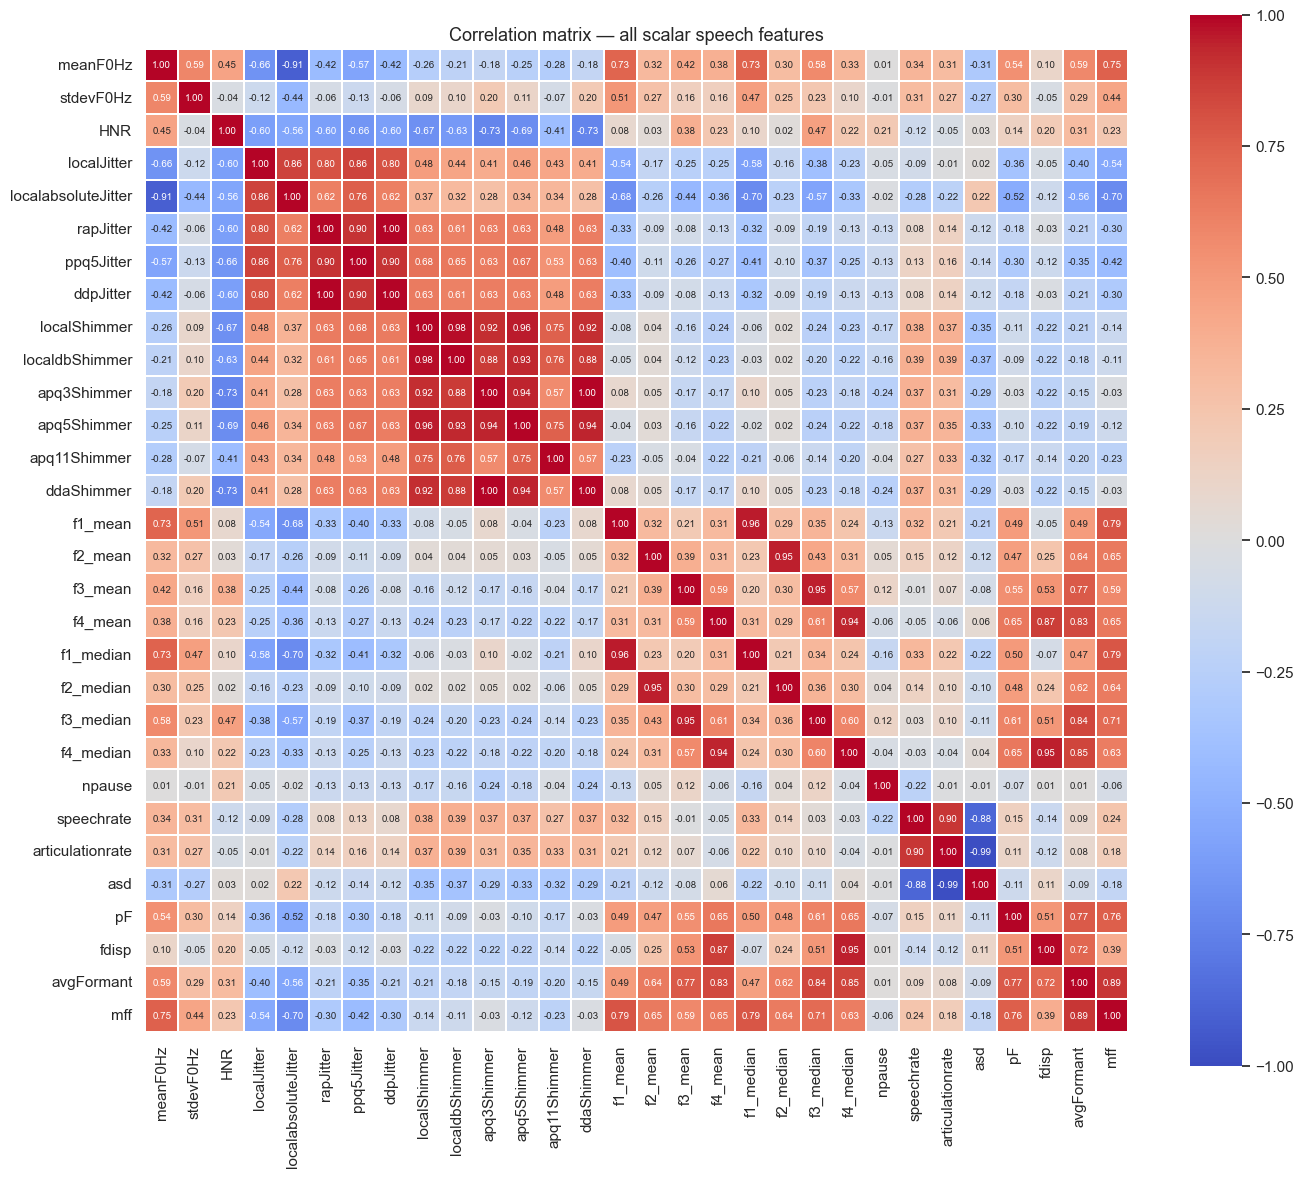

In [33]:
corr = data[scalar_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.3,
    annot_kws={'size': 7},
    ax=ax
)
ax.set_title('Correlation matrix — all scalar speech features', fontsize=13)
plt.tight_layout()
plt.show()

In [34]:
# Show top non-trivial correlations (cross-feature, |r| > 0.4)
corr_vals = corr.abs().unstack()
corr_vals = corr_vals[corr_vals < 1.0]  # exclude self

# Remove symmetric duplicates
seen = set()
rows = []
for (a, b), v in corr_vals.sort_values(ascending=False).items():
    key = tuple(sorted([a, b]))
    if key not in seen and v > 0.4:
        seen.add(key)
        rows.append({'feature_a': a, 'feature_b': b, 'correlation': round(corr.loc[a, b], 3)})

pd.DataFrame(rows)

,feature_a,feature_b,correlation
0,apq3Shimmer,ddaShimmer,1.000
1,asd,articulationrate,-0.986
2,localShimmer,localdbShimmer,0.977
3,localShimmer,apq5Shimmer,0.959
4,f1_median,f1_mean,0.956
...,...,...,...
130,ddpJitter,meanF0Hz,-0.416
131,HNR,apq11Shimmer,-0.412
132,f1_median,ppq5Jitter,-0.408
133,apq3Shimmer,localJitter,0.406


## Bivariate scatter plots

Plotting the most interesting cross-group pairs, colored by candidate.

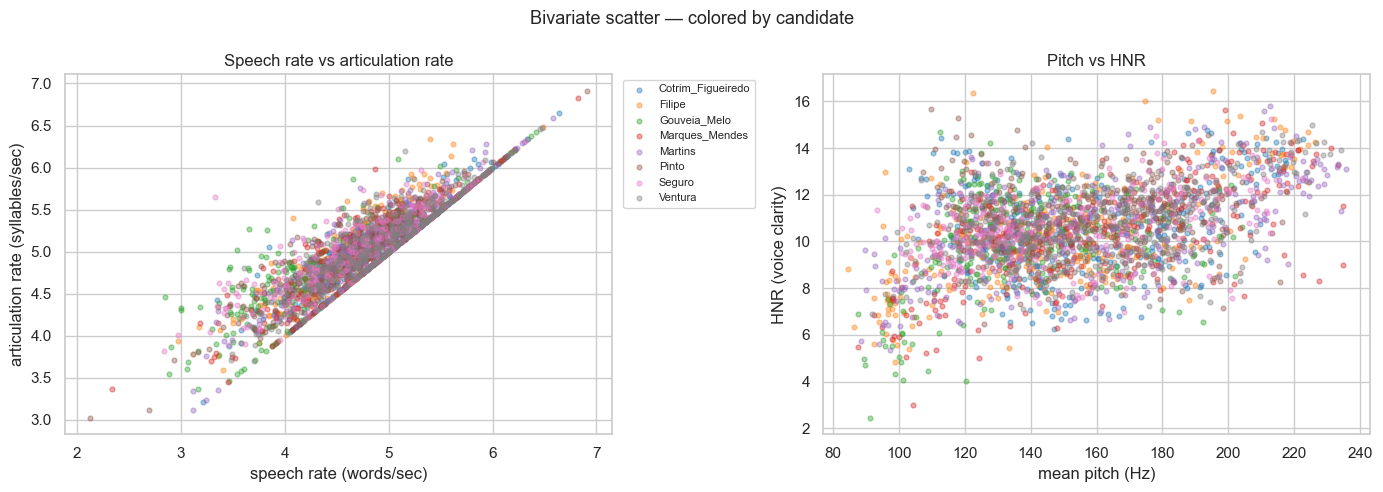

In [35]:
# Speech rate vs articulation rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

candidates = sorted(data['candidate'].dropna().unique())
palette = sns.color_palette('tab10', len(candidates))
color_map = dict(zip(candidates, palette))

for cand in candidates:
    sub = data[data['candidate'] == cand]
    axes[0].scatter(sub['speechrate'], sub['articulationrate'],
                    alpha=0.4, s=12, label=cand, color=color_map[cand])

axes[0].set_xlabel('speech rate (words/sec)')
axes[0].set_ylabel('articulation rate (syllables/sec)')
axes[0].set_title('Speech rate vs articulation rate')
axes[0].legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')

# Pitch vs HNR
for cand in candidates:
    sub = data[data['candidate'] == cand]
    axes[1].scatter(sub['meanF0Hz'], sub['HNR'],
                    alpha=0.4, s=12, label=cand, color=color_map[cand])

axes[1].set_xlabel('mean pitch (Hz)')
axes[1].set_ylabel('HNR (voice clarity)')
axes[1].set_title('Pitch vs HNR')

plt.suptitle('Bivariate scatter — colored by candidate', fontsize=13)
plt.tight_layout()
plt.show()

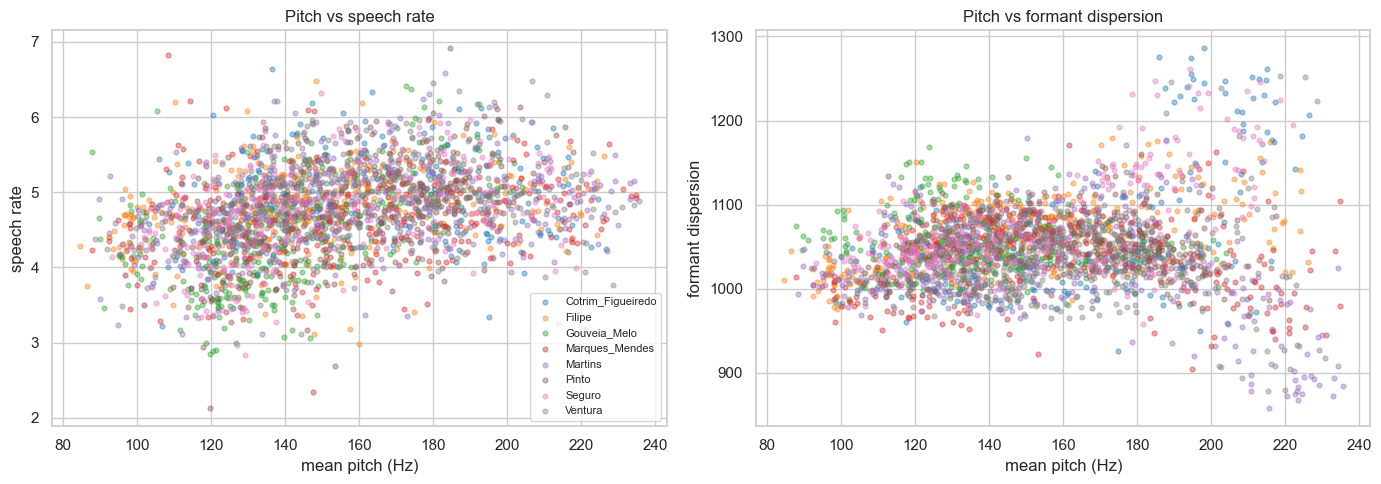

In [36]:
# Pitch vs speech rate, and formant dispersion vs pitch
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cand in candidates:
    sub = data[data['candidate'] == cand]
    axes[0].scatter(sub['meanF0Hz'], sub['speechrate'],
                    alpha=0.4, s=12, label=cand, color=color_map[cand])

axes[0].set_xlabel('mean pitch (Hz)')
axes[0].set_ylabel('speech rate')
axes[0].set_title('Pitch vs speech rate')
axes[0].legend(fontsize=8)

for cand in candidates:
    sub = data[data['candidate'] == cand]
    axes[1].scatter(sub['meanF0Hz'], sub['fdisp'],
                    alpha=0.4, s=12, label=cand, color=color_map[cand])

axes[1].set_xlabel('mean pitch (Hz)')
axes[1].set_ylabel('formant dispersion')
axes[1].set_title('Pitch vs formant dispersion')

plt.tight_layout()
plt.show()

## Candidate comparison — box plots

Do candidates differ in how they speak? Box plots for each key feature grouped by candidate.

C:\Users\dinis\AppData\Local\Temp\ipykernel_15596\127046591.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\dinis\AppData\Local\Temp\ipykernel_15596\127046591.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\dinis\AppData\Local\Temp\ipykernel_15596\127046591.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\dinis\AppData\Local\Temp\ipykernel_15596\127046591.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

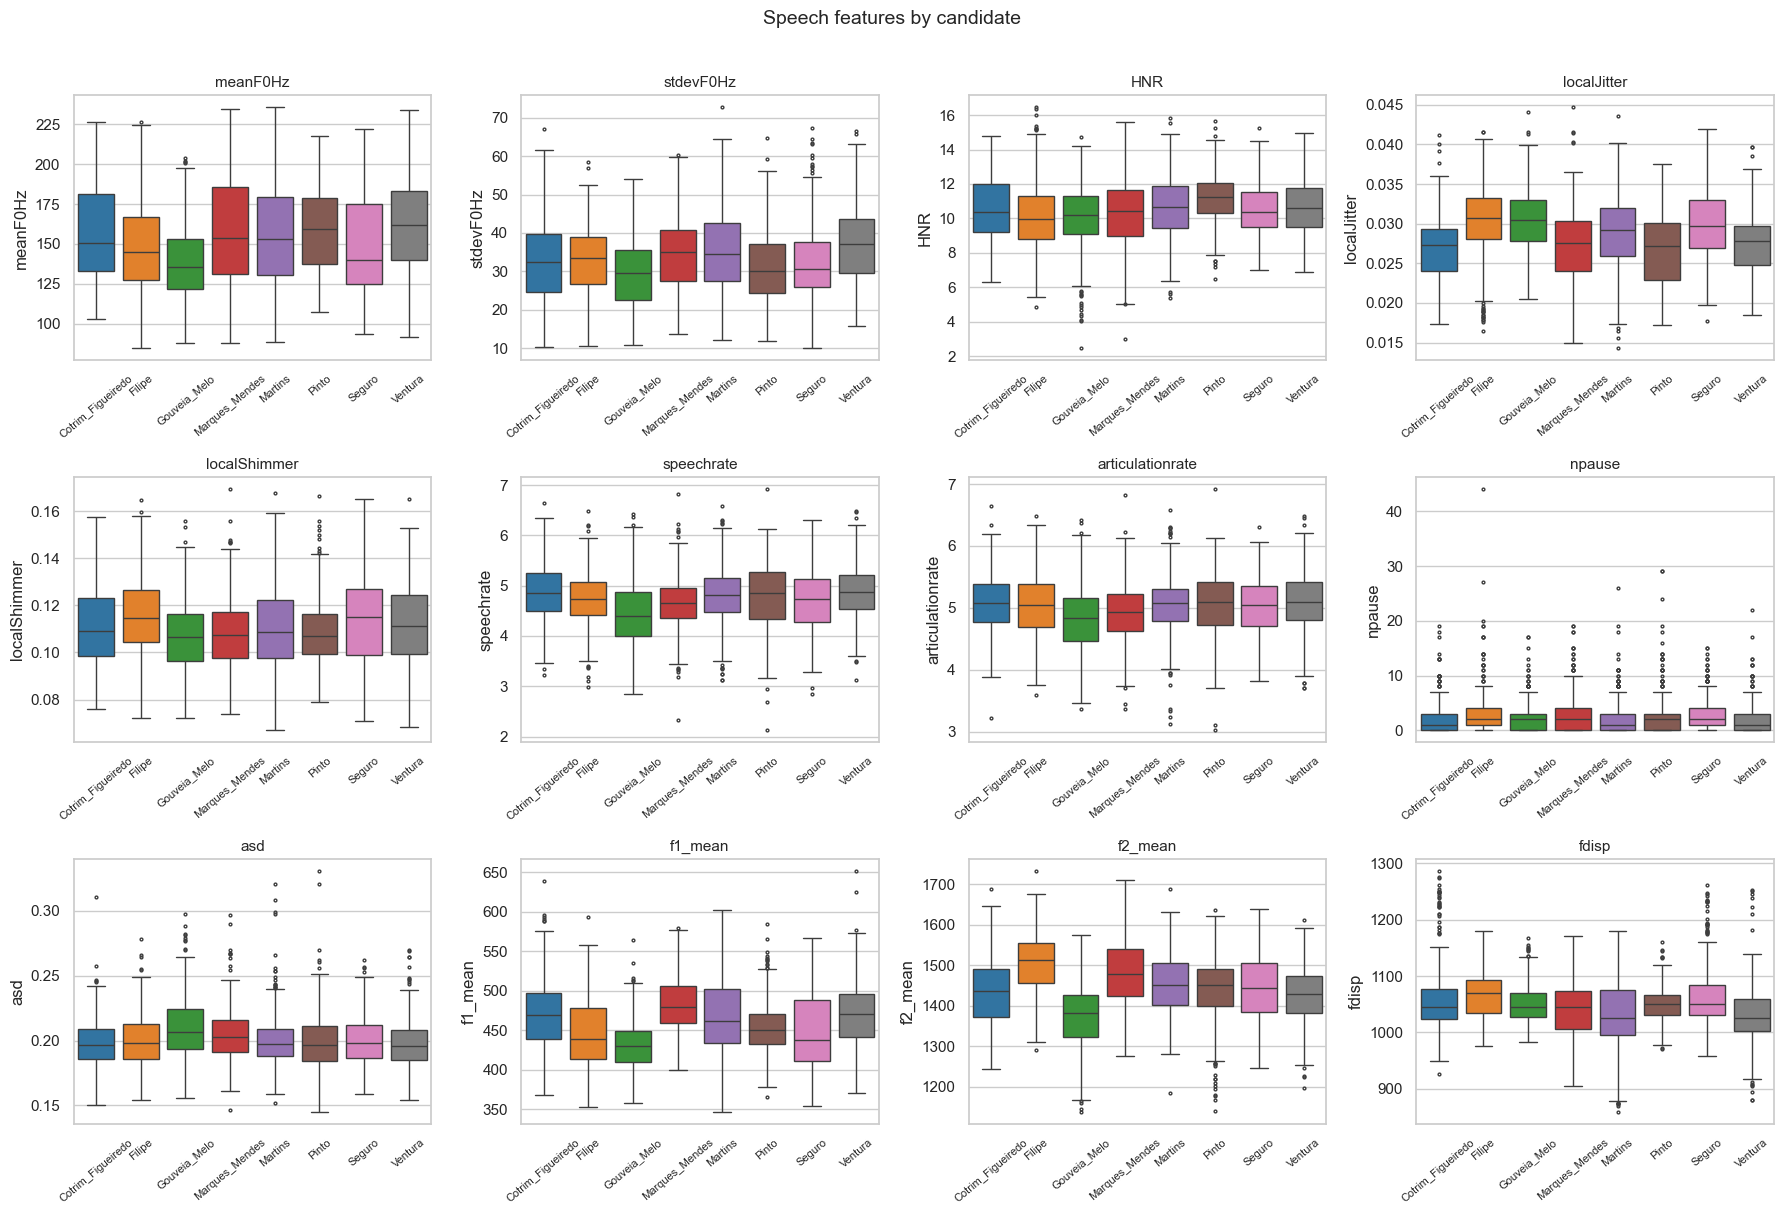

In [37]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(KEY_FEATURES):
    plot_data = data[['candidate', col]].dropna()
    sns.boxplot(
        data=plot_data, x='candidate', y=col,
        ax=axes[i], palette='tab10',
        order=candidates, fliersize=2
    )
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=40, labelsize=8)

plt.suptitle('Speech features by candidate', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

C:\Users\dinis\AppData\Local\Temp\ipykernel_15596\2234353580.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\dinis\AppData\Local\Temp\ipykernel_15596\2234353580.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\dinis\AppData\Local\Temp\ipykernel_15596\2234353580.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\dinis\AppData\Local\Temp\ipykernel_15596\2234353580.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

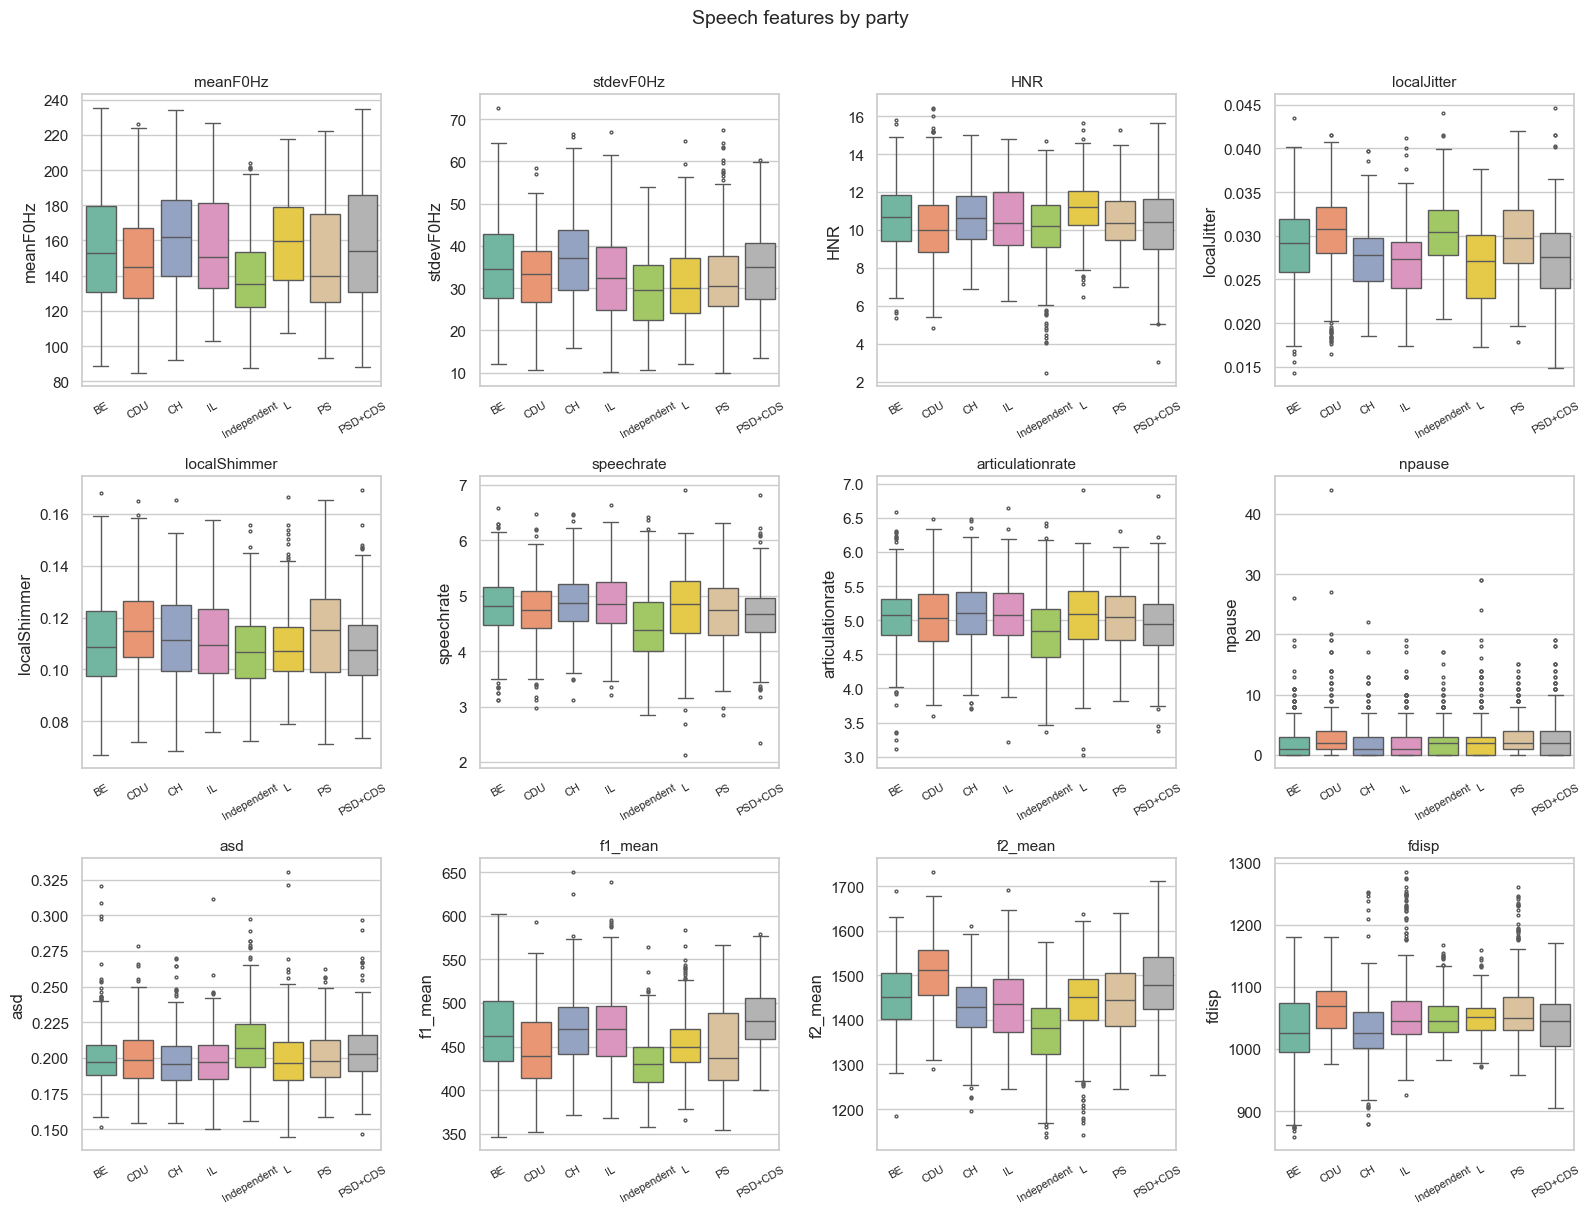

In [38]:
# Same but grouped by party (higher level view)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()
parties = sorted(data['party'].dropna().unique())

for i, col in enumerate(KEY_FEATURES):
    plot_data = data[['party', col]].dropna()
    sns.boxplot(
        data=plot_data, x='party', y=col,
        ax=axes[i], palette='Set2',
        order=parties, fliersize=2
    )
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)

plt.suptitle('Speech features by party', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Speaker embeddings — PCA projection

The `speak_embeddings` column stores a 512-dim vector encoding voice identity.
We reduce to 2D with PCA to check whether candidates cluster visually.

Embedding matrix: (2656, 512)
Explained variance: PC1=9.9%  PC2=9.6%


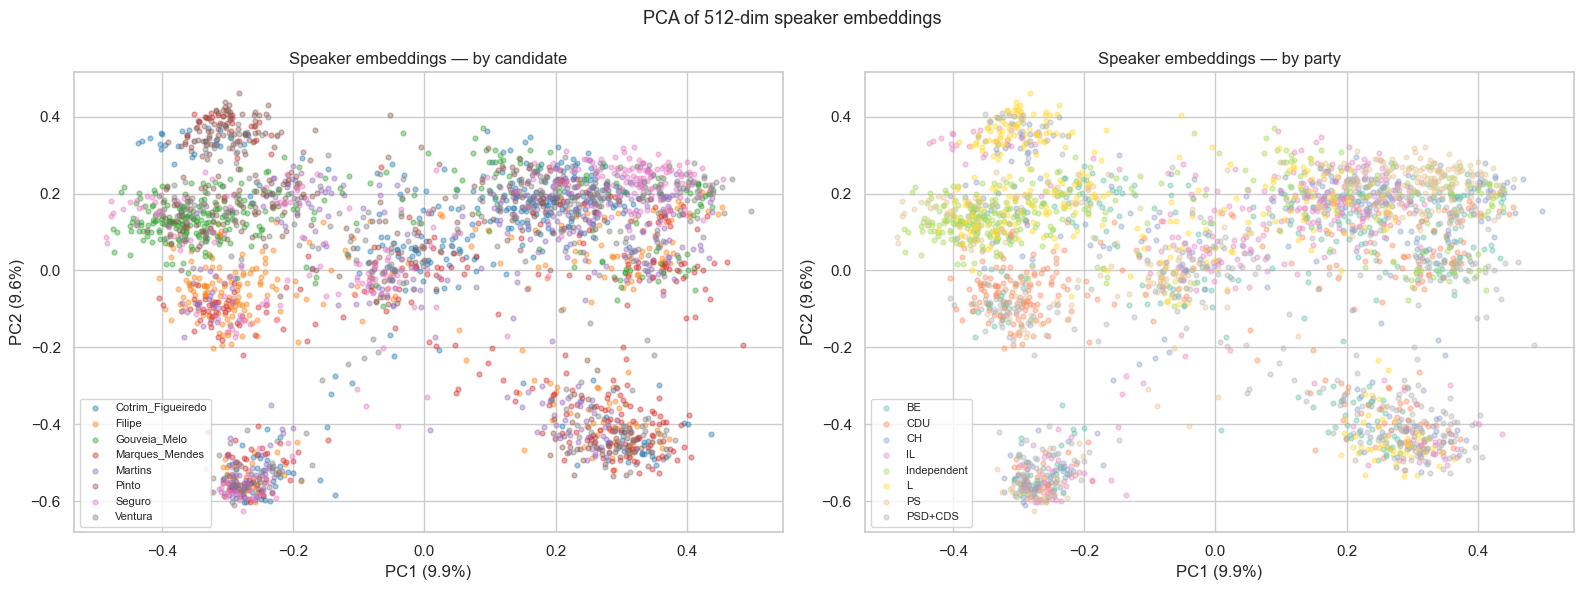

In [39]:
embeddings = np.stack(data['speak_embeddings'].values)
print('Embedding matrix:', embeddings.shape)

pca = PCA(n_components=2)
emb_2d = pca.fit_transform(embeddings)
print(f'Explained variance: PC1={pca.explained_variance_ratio_[0]*100:.1f}%  PC2={pca.explained_variance_ratio_[1]*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Colored by candidate
for cand in candidates:
    mask = data['candidate'] == cand
    axes[0].scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                    label=cand, alpha=0.4, s=12, color=color_map[cand])
axes[0].set_title('Speaker embeddings — by candidate')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(fontsize=8)

# Colored by party
party_palette = sns.color_palette('Set2', len(parties))
party_color_map = dict(zip(parties, party_palette))
for party in parties:
    mask = data['party'] == party
    axes[1].scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                    label=party, alpha=0.4, s=12, color=party_color_map[party])
axes[1].set_title('Speaker embeddings — by party')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend(fontsize=8)

plt.suptitle('PCA of 512-dim speaker embeddings', fontsize=13)
plt.tight_layout()
plt.show()

## Mean feature profile per candidate

A summary table of average values for each key feature, per candidate.
Useful for the presentation — gives a one-line characterization of each speaker's style.

In [40]:
profile = data.groupby('candidate')[KEY_FEATURES].mean().round(3)
profile

,meanF0Hz,stdevF0Hz,HNR,localJitter,localShimmer,speechrate,articulationrate,npause,asd,f1_mean,f2_mean,fdisp
candidate,,,,,,,,,,,,
Cotrim_Figueiredo,156.873,32.903,10.554,0.027,0.112,4.882,5.078,2.325,0.199,472.172,1435.892,1059.152
Filipe,147.793,32.996,10.195,0.030,0.115,4.731,5.040,3.245,0.200,446.419,1504.146,1065.950
Gouveia_Melo,139.217,29.652,10.019,0.031,0.107,4.443,4.825,2.333,0.210,433.335,1372.394,1051.922
Marques_Mendes,158.321,34.426,10.330,0.027,0.109,4.667,4.929,2.891,0.205,483.625,1482.150,1038.033
Martins,157.108,35.593,10.583,0.029,0.110,4.815,5.048,2.325,0.200,468.217,1455.056,1028.935
Pinto,158.218,30.971,11.139,0.027,0.109,4.776,5.047,2.820,0.200,453.254,1437.599,1051.004
Seguro,149.335,32.439,10.490,0.030,0.113,4.696,5.032,2.818,0.200,448.355,1446.783,1066.399
Ventura,162.816,36.913,10.717,0.027,0.112,4.894,5.103,2.075,0.198,470.277,1424.336,1031.427


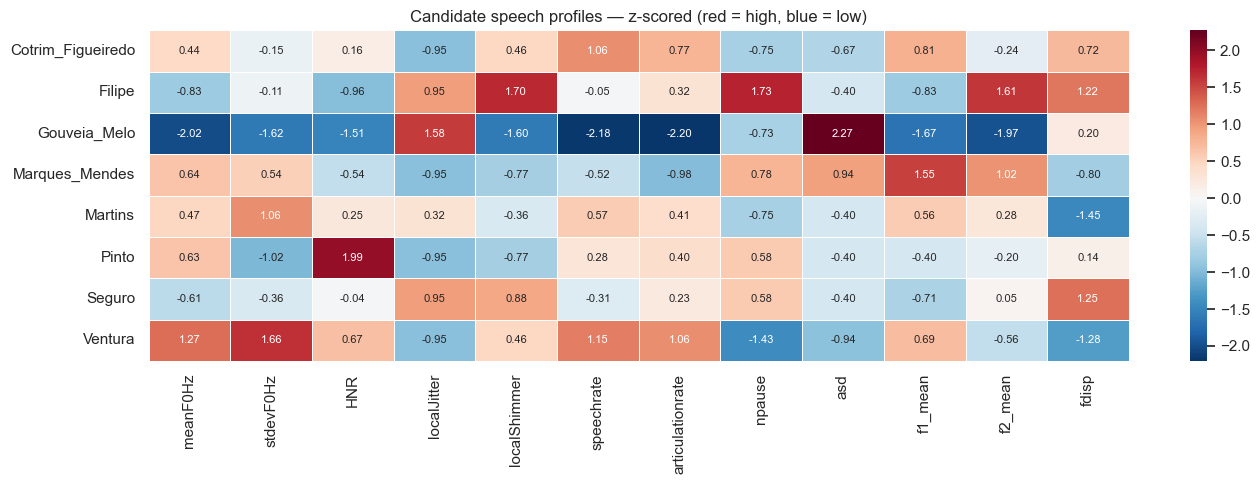

In [41]:
# Heatmap of normalized feature profiles — who is high/low on each feature?
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
profile_norm = pd.DataFrame(
    scaler.fit_transform(profile),
    index=profile.index,
    columns=profile.columns
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    profile_norm,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    linewidths=0.4,
    annot_kws={'size': 8},
    ax=ax
)
ax.set_title('Candidate speech profiles — z-scored (red = high, blue = low)', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## Data quality notes

A few things worth mentioning in the midterm presentation:

- No missing values in any feature column — the extraction pipeline was complete.
- There is no explicit speaker label in the audio pkl. Candidate assignment here was done by
  k-means clustering (k=2) of the 512-dim speaker embeddings within each debate file,
  then mapping cluster ids to the two candidate names extracted from the filename.
  This assignment may have errors — the two clusters might be swapped for some debates.
- Segment counts per debate range from 63 to 128, reflecting different debate durations
  and speaking patterns.
- The jitter and shimmer columns each contain ~6 variants measuring the same underlying
  property at different scales. They are highly correlated — for modeling purposes,
  only one representative per group is needed.

In [42]:
print('Segments per candidate (after k-means labeling):')
print(data['candidate'].value_counts())
print()
print('Segments per party:')
print(data['party'].value_counts())

Segments per candidate (after k-means labeling):
candidate
Martins              372
Pinto                334
Ventura              333
Cotrim_Figueiredo    332
Gouveia_Melo         330
Filipe               322
Marques_Mendes       320
Seguro               313
Name: count, dtype: int64

Segments per party:
party
BE             372
L              334
CH             333
IL             332
Independent    330
CDU            322
PSD+CDS        320
PS             313
Name: count, dtype: int64


## Opening the speech pkl

The `*_speech.pkl` is a separate file from the audio pkl. It stores the Whisper transcript
and the 4096-dim EuroLLM embedding for each audio segment. The rows align 1:1 with the audio pkl.

In [43]:
speech_files = sorted([
    f for f in os.listdir('Project_Features')
    if f.endswith('_speech.pkl')
])

print(f'Found {len(speech_files)} speech files')
print(speech_files[:5], '...')

Found 42 speech files
['Cotrim_Figueiredo_vs_Filipe_November_30_speech.pkl', 'Cotrim_Figueiredo_vs_Gouveia_Melo_November_20_speech.pkl', 'Cotrim_Figueiredo_vs_Marques_Mendes_December_7_speech.pkl', 'Cotrim_Figueiredo_vs_Ventura_December_19_speech.pkl', 'Filipe_vs_Gouveia_Melo_December_2_speech.pkl'] ...


In [44]:
# Load all speech files and concatenate
speech_dfs = []
for f in speech_files:
    df = pd.read_pickle(os.path.join('Project_Features', f))
    df['video'] = f.replace('_speech.pkl', '')
    speech_dfs.append(df)

data_speech = pd.concat(speech_dfs, ignore_index=True)
print(f'Shape: {data_speech.shape}')
print(f'Columns: {list(data_speech.columns)}')

Shape: (1407, 5)
Columns: ['timestamp', 'duration', 'transcript', 'text_embedding', 'video']


In [45]:
# Inspect a single row
data_speech.iloc[0]

timestamp                                                     0.031
duration                                                     40.939
transcript         Boa noite. A caminho das presidenciais, esta ...
text_embedding    [1.8727678, -0.23335643, 0.4982911, 0.03197212...
video                       Cotrim_Figueiredo_vs_Filipe_November_30
Name: 0, dtype: object

In [46]:
# Check missing values
print('Missing values:')
print(data_speech.isnull().sum())
print()

# Check dtypes
print('Dtypes:')
print(data_speech.dtypes)

Missing values:
timestamp         0
duration          0
transcript        0
text_embedding    0
video             0
dtype: int64

Dtypes:
timestamp                 float64
duration                  float64
transcript        string[pyarrow]
text_embedding             object
video                      object
dtype: object


In [47]:
# Look at a few transcripts
print('=== Sample transcripts ===')
for i in [0, 5, 10, 20]:
    print(f'\n[segment {i}]')
    print(data_speech.iloc[i]['transcript'])

=== Sample transcripts ===

[segment 0]
 Boa noite. A caminho das presidenciais, esta noite, o debate é entre João, com Trinfigaredo e Antonio Felipe, bem-vindos, o sorteio de toque começa. Antonio Felipe, e termina com Trinfigaredo. Antonio Felipe, como sempre nós abrimos com um tema da atualidade, começamos por que os português esperam do próximo presidente e uma sondagem divulgada esta semana indica que querem um presidente mais interventivo com uma visão clara para o país e capaz de obrigar o Governo a agir. O que o pergunta é se for ilet, como é que vai exercer esse papel mais interventivo? Se pensa, obrigar o Governo a agir de alguma forma, de forma diferente, nomeadamente, aquilo que o atual presidente tem feito até agora. Boa noite, pessoal.

[segment 5]
 E o antefeiço que o PCP do Ojão mudou. O PCP queria fazer um referente para sair do Euro. Sabe que esse referente não é possível, costicionalmente, o que se defendeu na altura aqui, ou que ele não gostou aqui com partidos, o d

In [48]:
# Check transcript embedding shape
embed_col = [c for c in data_speech.columns if 'embed' in c.lower()]
print('Embedding columns:', embed_col)

if embed_col:
    sample_emb = data_speech.iloc[0][embed_col[0]]
    print(f'Embedding shape: {np.array(sample_emb).shape}')

Embedding columns: ['text_embedding']
Embedding shape: (4096,)


Word count per segment:
count    1407.00
mean      128.26
std        86.08
min        18.00
25%        75.00
50%       100.00
75%       147.00
max       712.00
Name: word_count, dtype: float64


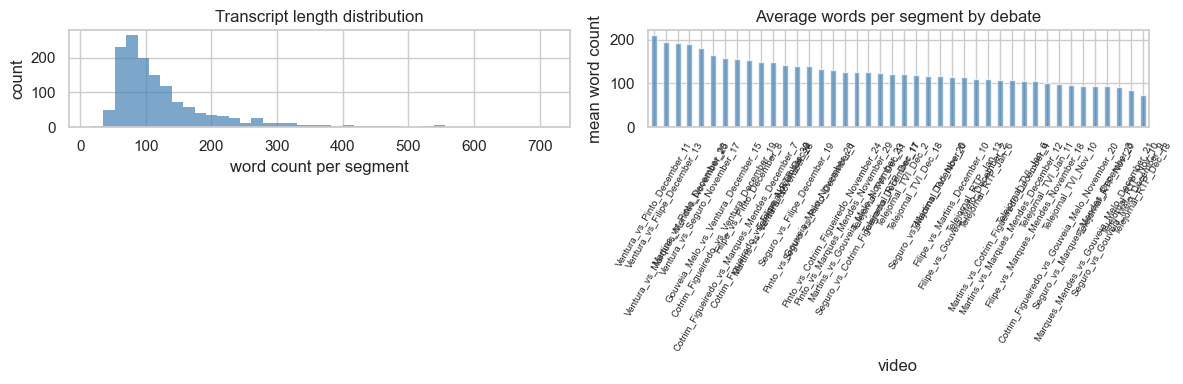

In [49]:
# Segment length distribution (word count from transcript)
data_speech['word_count'] = data_speech['transcript'].apply(
    lambda t: len(str(t).split()) if pd.notnull(t) else 0
)

print('Word count per segment:')
print(data_speech['word_count'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(data_speech['word_count'], bins=40, color='steelblue', alpha=0.7, edgecolor='none')
axes[0].set_xlabel('word count per segment')
axes[0].set_ylabel('count')
axes[0].set_title('Transcript length distribution')

# Words per segment grouped by video (proxy for candidate verbosity)
mean_words = data_speech.groupby('video')['word_count'].mean().sort_values(ascending=False)
mean_words.plot(kind='bar', ax=axes[1], color='steelblue', alpha=0.7)
axes[1].set_title('Average words per segment by debate')
axes[1].set_ylabel('mean word count')
axes[1].tick_params(axis='x', rotation=60, labelsize=7)

plt.tight_layout()
plt.show()

In [50]:
# Merge candidate labels from audio data into speech data
# Both should have the same number of rows and align by video + time stamp
# The safest merge is by (video, time stamp) since rows correspond to same segments

if 'time stamp' in data_speech.columns and 'time stamp' in data.columns:
    speech_labeled = data_speech.merge(
        data[['video', 'time stamp', 'candidate', 'party']],
        on=['video', 'time stamp'],
        how='left'
    )
    print(f'Merged shape: {speech_labeled.shape}')
    print('Candidate counts after merge:')
    print(speech_labeled['candidate'].value_counts())
else:
    # Fall back to positional merge within each video
    print('No time stamp column — merging by position within video')
    speech_labeled = data_speech.copy()
    speech_labeled['candidate'] = data['candidate'].values
    speech_labeled['party'] = data['party'].values

No time stamp column — merging by position within video


ValueError: Length of values (2656) does not match length of index (1407)

Transcript embedding matrix: (1407, 4096)
Explained variance: PC1=17.2%  PC2=10.3%


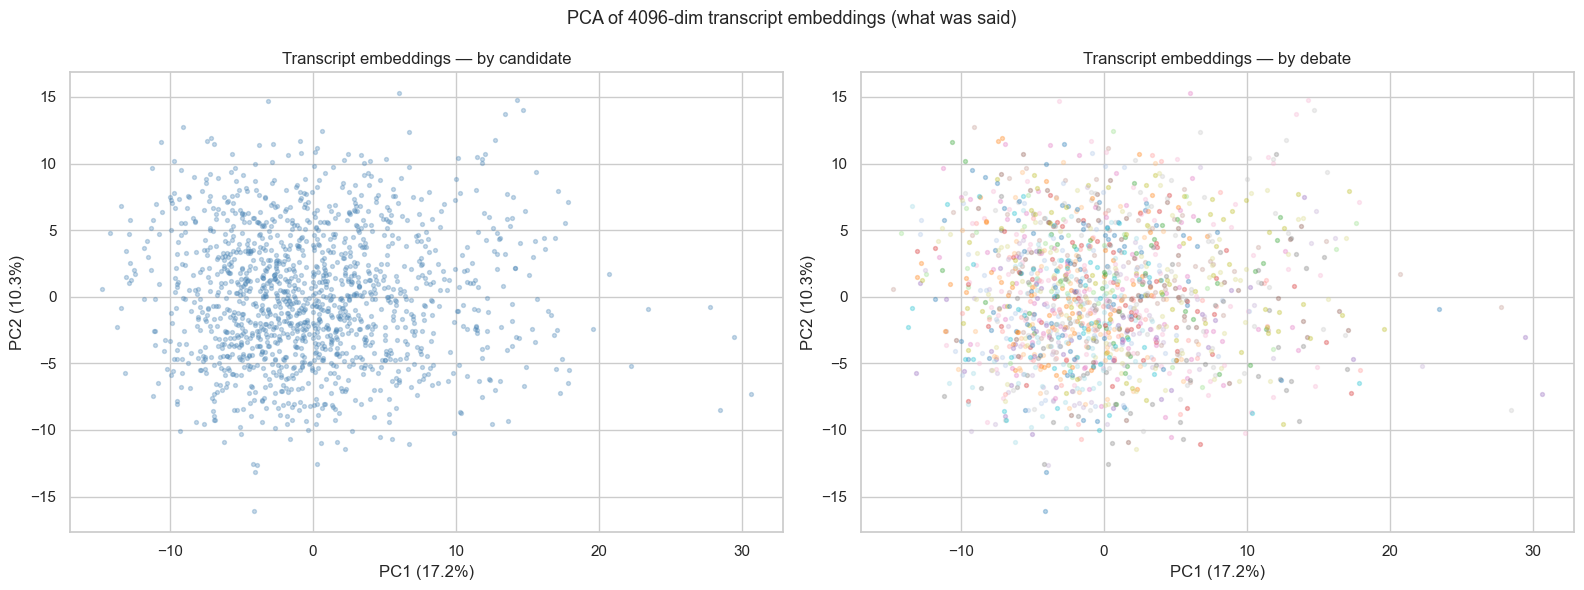

In [51]:
# PCA of transcript embeddings — colored by candidate
# This shows whether candidates talk about different topics

if embed_col:
    t_embeddings = np.stack(data_speech[embed_col[0]].values)
    print(f'Transcript embedding matrix: {t_embeddings.shape}')

    pca_t = PCA(n_components=2)
    t_2d = pca_t.fit_transform(t_embeddings)
    print(f'Explained variance: PC1={pca_t.explained_variance_ratio_[0]*100:.1f}%  PC2={pca_t.explained_variance_ratio_[1]*100:.1f}%')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # By candidate
    if 'candidate' in speech_labeled.columns:
        for cand in sorted(speech_labeled['candidate'].dropna().unique()):
            mask = (speech_labeled['candidate'] == cand).values
            axes[0].scatter(t_2d[mask, 0], t_2d[mask, 1],
                            label=cand, alpha=0.3, s=10)
        axes[0].legend(fontsize=8)
    else:
        axes[0].scatter(t_2d[:, 0], t_2d[:, 1], alpha=0.3, s=8, color='steelblue')

    axes[0].set_title('Transcript embeddings — by candidate')
    axes[0].set_xlabel(f'PC1 ({pca_t.explained_variance_ratio_[0]*100:.1f}%)')
    axes[0].set_ylabel(f'PC2 ({pca_t.explained_variance_ratio_[1]*100:.1f}%)')

    # By debate (video)
    videos = data_speech['video'].unique()
    palette_v = sns.color_palette('tab20', len(videos))
    for i, vid in enumerate(videos):
        mask = (data_speech['video'] == vid).values
        axes[1].scatter(t_2d[mask, 0], t_2d[mask, 1],
                        alpha=0.3, s=8, color=palette_v[i])

    axes[1].set_title('Transcript embeddings — by debate')
    axes[1].set_xlabel(f'PC1 ({pca_t.explained_variance_ratio_[0]*100:.1f}%)')
    axes[1].set_ylabel(f'PC2 ({pca_t.explained_variance_ratio_[1]*100:.1f}%)')

    plt.suptitle('PCA of 4096-dim transcript embeddings (what was said)', fontsize=13)
    plt.tight_layout()
    plt.show()